# AI Productivity Prediction — Stack Overflow 2025

This notebook builds an end-to-end pipeline to predict whether a professional developer agrees that AI agents have increased their productivity. The flow is: define a binary target from the survey's AIAgentImpact Likert matrix, restrict to a professional-developer cohort, select a whitelist of 26 raw columns with direct theoretical link to AI productivity, engineer features (ordinals, counts, binary flags, bucketed role), run a missingness audit and EDA on pre-imputation data, then preprocess (median impute, conditional missingness indicators), one-hot encode categoricals, and fit baseline models to assess signal.

The target was chosen because the AIAgentImpact matrix contained one statement that directly measures perceived productivity from AI agents: "AI agents have increased my productivity." It is the most direct available proxy for AI productivity belief in the dataset. The data are from the 2025 Stack Overflow Developer Survey: 49,123 total respondents and 170 columns.

The cohort is restricted to professional developers because hobbyists, students, and the unemployed have fundamentally different relationships with productivity tooling; mixing them into a model targeting professional productivity would introduce confounding. After target construction, 12,758 rows have a label (8,768 agree, 3,990 disagree/neutral). After the cohort filter (MainBranch, Employment, WorkExp), 9,502 rows remain. The final model-ready matrix has 45 columns after one-hot encoding.

## 1. Data Loading

The raw file contains 49,123 survey responses and 170 columns covering demographics, tech stack, work habits, and AI usage. The print statement below confirms the shape.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("/kaggle/input/datasets/aliaslam25/stack-overflow-developer-survey-2025/survey_results_public.csv")
print(df.shape)

/tmp/ipykernel_17/1641870582.py:4: DtypeWarning: Columns (56,74,92,97,98,105,109,110,132,162,165) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/kaggle/input/datasets/aliaslam25/stack-overflow-developer-survey-2025/survey_results_public.csv")


(49191, 172)


## 2. Target Construction

The AIAgentImpact columns are a wide-format Likert matrix: each column corresponds to a response level (e.g. Strongly agree, Somewhat agree), and its value is a semicolon-separated list of statements the respondent placed at that level. The target is built by searching for the exact string "AI agents have increased my productivity" in the two agree-level columns and the three disagree/neutral columns. Rows where the string does not appear in any of those five columns are dropped; these are not abstentions but respondents who were not shown or did not reach the agent impact question. The result is 12,758 labeled rows from the original 49,123.

In [2]:
PRODUCTIVITY_STR = "AI agents have increased my productivity"
agree_cols = ["AIAgentImpactStrongly agree", "AIAgentImpactSomewhat agree"]
disagree_cols = ["AIAgentImpactNeutral", "AIAgentImpactSomewhat disagree", "AIAgentImpactStrongly disagree"]

def get_target(row):
    for c in agree_cols:
        if pd.notna(row[c]) and PRODUCTIVITY_STR in str(row[c]):
            return 1
    for c in disagree_cols:
        if pd.notna(row[c]) and PRODUCTIVITY_STR in str(row[c]):
            return 0
    return np.nan

df["target"] = df.apply(get_target, axis=1)
df = df[df["target"].notna()].copy()
print(df["target"].value_counts().to_string())

target
1.0    8776
0.0    3995


## 3. Cohort Filter

Three conditions are applied. MainBranch = "I am a developer by profession" removes hobbyists and students whose AI tool usage is driven by personal curiosity rather than professional productivity pressure. The Employment filter keeps only Employed or Independent contractor, freelancer, or self-employed, dropping the unemployed and retired who have no professional context in which to evaluate AI's effect on their work. WorkExp not null and not 0 removes respondents who likely misreported or are at the very start of their career where productivity assessment is unreliable. The filter reduces rows from 12,758 to 9,502 (a drop of 3,256). This is intentional: the model is scoped to practicing professional developers.

In [3]:
employment_ok = df["Employment"].isin(["Employed", "Independent contractor, freelancer, or self-employed"])
df = df[
    (df["MainBranch"] == "I am a developer by profession")
    & employment_ok
    & df["WorkExp"].notna()
    & (df["WorkExp"] != 0)
].copy()
print(df.shape)

(9513, 173)


## 4. Column Selection

The raw dataset has 170 columns (OS preference, Stack Overflow visit frequency, and much else). Rather than dropping irrelevant columns one by one, a whitelist of 26 columns with a direct theoretical link to AI productivity perception was defined. The three groups are: (1) AI attitude and usage — the core signal (how often and how positively the respondent uses AI); (2) AI tooling — which LLMs and editors they use, later engineered into counts and binary flags; (3) developer profile — experience, role, org size, industry — as demographic controls. Everything else (language choices, framework preferences, Stack Overflow engagement, compensation, tech purchasing) was excluded as having no direct theoretical link to AI productivity sentiment.

In [4]:
WHITELIST = [
    "AISelect", "AISent", "AIAcc", "AIComplex", "AIFrustration", "AIAgents", "AIAgentChange",
    "AIAgent_Uses", "AgentUsesGeneral", "AIHuman",
    "AIToolCurrently mostly AI", "AIToolCurrently partially AI", "AIToolPlan to mostly use AI",
    "AIToolPlan to partially use AI", "AIToolDon't plan to use AI for this task",
    "AIModelsHaveWorkedWith", "DevEnvsHaveWorkedWith",
    "DevType", "WorkExp", "YearsCode", "OrgSize", "ICorPM", "RemoteWork", "Age", "EdLevel", "Industry",
]
cols = [c for c in WHITELIST if c in df.columns]
missing = set(WHITELIST) - set(cols)
if missing:
    print("Missing from data:", missing)
df = df[["target"] + cols].copy()
print(df.shape)

(9513, 27)


## 5. Feature Engineering

Four transformation types are applied. Raw string columns cannot be used by sklearn. Ordinals: eight categorical columns with a natural rank order (AI usage frequency, trust, sentiment) are mapped to integers 0–4 using exact survey strings; the `norm()` function handles a known UTF-8 replacement character in some responses. Count features: seven multi-select string columns become integer counts of semicolon-separated items (e.g. `ai_tasks_now` counts how many development tasks the respondent currently handles with AI). Binary flags: `has_ai_editor` and the five `uses_*` model-family flags use case-insensitive substring matching. DevType bucketing: the raw `DevType` field is highly granular and multi-select; only the first role is used and collapsed into four buckets to avoid sparse encoding.

In [5]:
# --- Ordinal mappings (exact strings)
AISELECT_MAP = {
    "Yes, I use AI tools daily": 4, "Yes, I use AI tools weekly": 3,
    "Yes, I use AI tools monthly or infrequently": 2, "No, but I plan to soon": 1, "No, and I don't plan to": 0,
}
AISENT_MAP = {"Very favorable": 4, "Favorable": 3, "Indifferent": 2, "Unfavorable": 1, "Very unfavorable": 0}
AIACC_MAP = {"Highly trust": 4, "Somewhat trust": 3, "Neither trust nor distrust": 2, "Somewhat distrust": 1, "Highly distrust": 0}
AICOMPLEX_MAP = {
    "Very well at handling complex tasks": 4, "Good, but not great at handling complex tasks": 3,
    "Neither good or bad at handling complex tasks": 2, "Bad at handling complex tasks": 1, "Very poor at handling complex tasks": 0,
    "I don't use AI tools for complex tasks / I don't know": 2,
}
AIAGENTS_MAP = {
    "Yes, I use AI agents at work daily": 4, "Yes, I use AI agents at work weekly": 3,
    "Yes, I use AI agents at work monthly or infrequently": 2,
    "No, I use AI exclusively in copilot/autocomplete mode": 1, "No, but I plan to": 1, "No, and I don't plan to": 0,
}
AGENT_CHANGE_MAP = {
    "Yes, to a great extent": 2, "Yes, somewhat": 1,
    "Not at all or minimally": 0,
    "No, but my development work has changed somewhat due to non-AI factors": 0,
    "No, but my development work has significantly changed due to non-AI factors": 0,
}
ORGSIZE_MAP = {
    "Just me - I am a freelancer, sole proprietor, etc.": 0, "Less than 20 employees": 1, "20 to 99 employees": 2,
    "100 to 499 employees": 3, "500 to 999 employees": 4, "1,000 to 4,999 employees": 5,
    "5,000 to 9,999 employees": 6, "10,000 or more employees": 7, "I don't know": np.nan,
}
AGE_MAP = {
    "Under 18 years old": 0, "18-24 years old": 1, "25-34 years old": 2, "35-44 years old": 3,
    "45-54 years old": 4, "55-64 years old": 5, "65 years or older": 6, "Prefer not to say": np.nan,
}
EDLEVEL_MAP = {
    "Primary/elementary school": 0, "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": 1,
    "Some college/university study without earning a degree": 2, "Associate degree (A.A., A.S., etc.)": 3,
    "Bachelor's degree (B.A., B.S., B.Eng., etc.)": 4, "Master's degree (M.A., M.S., M.Eng., MBA, etc.)": 5,
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": 6, "Other (please specify):": np.nan,
}

def count_semi(s):
    if pd.isna(s) or str(s).strip() == "":
        return 0
    return len([x for x in str(s).split(";") if x.strip()])

# Normalize common encoding (e.g. replacement char) so ordinal maps match
def norm(s):
    return str(s).replace("\ufffd", "'") if pd.notna(s) else s

df["aiselect_ord"] = df["AISelect"].map(AISELECT_MAP)
df["aisent_ord"] = df["AISent"].map(AISENT_MAP)
df["AIAcc_ord"] = df["AIAcc"].map(AIACC_MAP)
df["AIComplex_ord"] = df["AIComplex"].map(AICOMPLEX_MAP)
df["aifrust_count"] = df["AIFrustration"].apply(count_semi)
df["aiagents_ord"] = df["AIAgents"].map(AIAGENTS_MAP)
df["agent_change_ord"] = df["AIAgentChange"].map(AGENT_CHANGE_MAP)

uses = df["AIAgent_Uses"].fillna("").astype(str) + ";" + df["AgentUsesGeneral"].fillna("").astype(str)
df["agent_use_breadth"] = uses.apply(lambda s: count_semi(s) if s.strip() != ";" else 0)

df["ai_tasks_now"] = (df["AIToolCurrently mostly AI"].apply(count_semi) + df["AIToolCurrently partially AI"].apply(count_semi))
df["ai_tasks_planned"] = (df["AIToolPlan to mostly use AI"].apply(count_semi) + df["AIToolPlan to partially use AI"].apply(count_semi))
df["ai_tasks_avoided"] = df["AIToolDon't plan to use AI for this task"].apply(count_semi)
df["aihuman_count"] = df["AIHuman"].apply(count_semi)

df["llm_count"] = df["AIModelsHaveWorkedWith"].apply(count_semi)
def has_sub(s, sub):
    return 1 if pd.notna(s) and sub.lower() in str(s).lower() else 0
df["uses_openai"] = df["AIModelsHaveWorkedWith"].apply(lambda s: has_sub(s, "openai") or has_sub(s, "gpt"))
df["uses_claude"] = df["AIModelsHaveWorkedWith"].apply(lambda s: has_sub(s, "claude"))
df["uses_gemini"] = df["AIModelsHaveWorkedWith"].apply(lambda s: has_sub(s, "gemini"))
df["uses_llama"] = df["AIModelsHaveWorkedWith"].apply(lambda s: has_sub(s, "llama"))
df["uses_deepseek"] = df["AIModelsHaveWorkedWith"].apply(lambda s: has_sub(s, "deepseek"))
for col in ["uses_openai", "uses_claude", "uses_gemini", "uses_llama", "uses_deepseek"]:
    df[col] = df[col].astype(int)

AI_EDITORS = ["Cursor", "Copilot", "Claude Code", "Cline", "Windsurf", "Bolt", "Lovable"]
def has_ai_editor(s):
    if pd.isna(s): return 0
    s = str(s).lower()
    return 1 if any(e.lower() in s for e in AI_EDITORS) else 0
df["has_ai_editor"] = df["DevEnvsHaveWorkedWith"].apply(has_ai_editor)

BUCKET_ORDER = [
    ("Data/AI", ["Data scientist", "Data engineer", "AI/ML engineer", "Applied scientist", "Data or business analyst"]),
    ("Infrastructure/Ops", ["Cloud infrastructure", "DevOps", "System administrator", "Cybersecurity", "InfoSec"]),
    ("Web/Software", ["Developer, front-end", "Developer, back-end", "Developer, full-stack", "Developer, desktop", "Developer, mobile", "Developer, QA", "Developer, game", "Developer, AI apps", "Architect, software"]),
]
def devtype_bucket(s):
    if pd.isna(s) or str(s).strip() == "": return "Other/Niche"
    first = str(s).split(";")[0].strip()
    for bucket, keywords in BUCKET_ORDER:
        if any(kw in first for kw in keywords): return bucket
    return "Other/Niche"
df["DevTypeBucket"] = df["DevType"].apply(devtype_bucket)

df["orgsize_ord"] = df["OrgSize"].apply(norm).map(ORGSIZE_MAP)
df["is_manager"] = (df["ICorPM"] == "People manager").astype(int)
df["age_ord"] = df["Age"].apply(norm).map(AGE_MAP)
df["edlevel_ord"] = df["EdLevel"].apply(norm).map(EDLEVEL_MAP)

industry_counts = df["Industry"].dropna().value_counts()
n_valid = industry_counts.sum()
threshold = max(1, int(0.03 * n_valid))
rare = industry_counts[industry_counts < threshold].index.tolist()
df["Industry"] = df["Industry"].where(~df["Industry"].isin(rare), "Other")

keep = ["target", "aiselect_ord", "aisent_ord", "AIAcc_ord", "AIComplex_ord", "aifrust_count", "aiagents_ord", "agent_change_ord",
        "agent_use_breadth", "ai_tasks_now", "ai_tasks_planned", "ai_tasks_avoided", "aihuman_count", "llm_count",
        "uses_openai", "uses_claude", "uses_gemini", "uses_llama", "uses_deepseek", "has_ai_editor", "DevTypeBucket",
        "WorkExp", "YearsCode", "orgsize_ord", "is_manager", "RemoteWork", "age_ord", "edlevel_ord", "Industry"]
df = df[keep].copy()
print(df.shape)

(9513, 29)


## 5b. Missingness Audit

This audit runs before imputation to see which columns have enough missing data to justify a missingness indicator. The threshold is 10%: columns above it may have systematic non-response that carries predictive signal. The output shows that `edlevel_ord` has 76.78% missingness. That reflects very high non-response on EdLevel among respondents who answered the agent impact questions, likely because they skipped the demographics block. Because of this rate and its non-random nature, no `_is_missing` indicator is added for it; it is median-imputed and treated as an unreliable feature. `orgsize_ord` at 11.15% technically exceeds the threshold but is also excluded by design — company size non-response is largely from freelancers who already have a value of 0.

In [6]:
num_cols_audit = [c for c in df.columns if c != "target" and pd.api.types.is_numeric_dtype(df[c])]
audit = pd.DataFrame({"col": num_cols_audit})
audit["null_count"] = audit["col"].map(lambda c: df[c].isna().sum())
audit["null_pct"] = (audit["null_count"] / len(df) * 100).round(2)
audit = audit.sort_values("null_pct", ascending=False)
print("Column       | null count | null %")
print("-" * 40)
for _, r in audit.iterrows():
    print(f"{r['col']:13} | {r['null_count']:>10} | {r['null_pct']:>6}%")
exceed_10 = audit[audit["null_pct"] > 10]["col"].tolist()
below_10 = audit[audit["null_pct"].between(0.01, 10)]["col"].tolist()
print("\nExceed 10% (get _is_missing):", exceed_10 if exceed_10 else "none")
print("Below 10% (impute only):", below_10 if below_10 else "none")
print("Excluded from _is_missing by design: orgsize_ord, edlevel_ord")

Column       | null count | null %
----------------------------------------
edlevel_ord   |       7306 |   76.8%
orgsize_ord   |       1059 |  11.13%
aisent_ord    |         88 |   0.93%
aiagents_ord  |         40 |   0.42%
agent_change_ord |         30 |   0.32%
AIAcc_ord     |         26 |   0.27%
YearsCode     |         22 |   0.23%
AIComplex_ord |         14 |   0.15%
age_ord       |          9 |   0.09%
aiselect_ord  |          7 |   0.07%
ai_tasks_now  |          0 |    0.0%
aifrust_count |          0 |    0.0%
agent_use_breadth |          0 |    0.0%
ai_tasks_planned |          0 |    0.0%
ai_tasks_avoided |          0 |    0.0%
aihuman_count |          0 |    0.0%
llm_count     |          0 |    0.0%
uses_llama    |          0 |    0.0%
uses_gemini   |          0 |    0.0%
uses_claude   |          0 |    0.0%
uses_openai   |          0 |    0.0%
WorkExp       |          0 |    0.0%
has_ai_editor |          0 |    0.0%
uses_deepseek |          0 |    0.0%
is_manager    |        

## 5c. Exploratory Data Analysis

EDA runs on pre-imputation data so that true distributions are visible and missingness is not masked. Five plots are produced: target balance, mean ordinal value by class, count feature distributions by class, a correlation heatmap, and a missingness bar chart.

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

sns.set_theme(style="whitegrid")

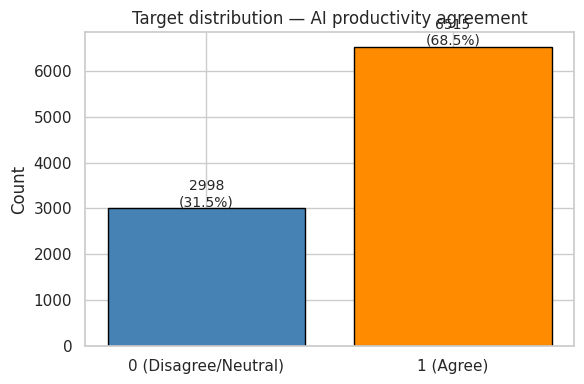

In [8]:
# Plot 1 — Target class balance
vc = df["target"].value_counts().sort_index()
pcts = (vc / len(df) * 100).round(1)
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar([0, 1], vc.values, color=["steelblue", "darkorange"], edgecolor="black")
ax.set_xticks([0, 1])
ax.set_xticklabels(["0 (Disagree/Neutral)", "1 (Agree)"])
ax.set_ylabel("Count")
ax.set_title("Target distribution — AI productivity agreement")
for bar, (cnt, pct) in zip(bars, zip(vc.values, pcts)):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50, f"{int(cnt)}\n({pct}%)", ha="center", fontsize=10)
plt.tight_layout()

The target is moderately imbalanced at 68.5% agree (n=6,508) vs 31.5% disagree/neutral (n=2,994) after the cohort filter. This is not severe enough to require oversampling, but all models in Section 9 use `class_weight="balanced"` to compensate.

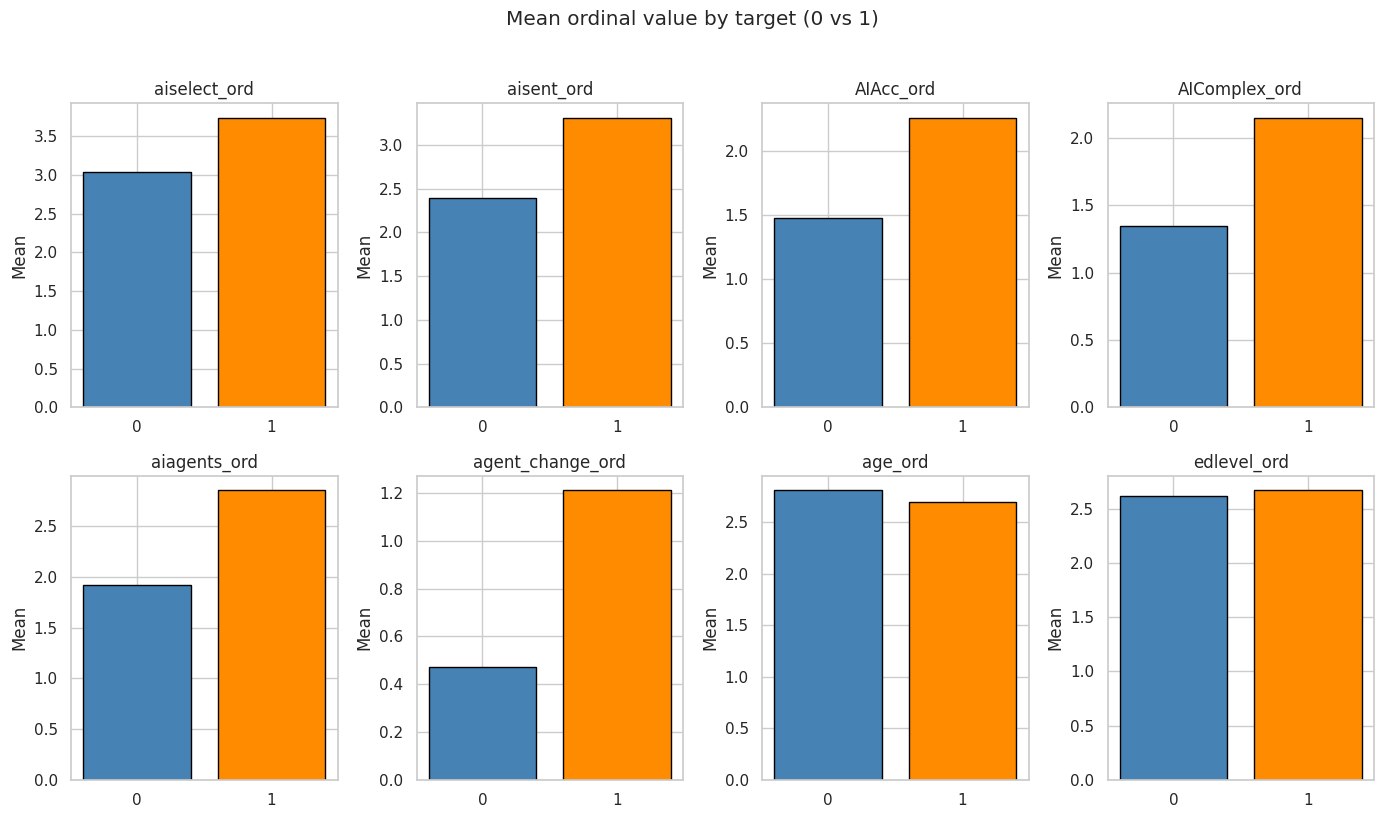

In [9]:
# Plot 2 — Ordinal features vs target (grouped means)
ord_cols = ["aiselect_ord", "aisent_ord", "AIAcc_ord", "AIComplex_ord", "aiagents_ord", "agent_change_ord", "age_ord", "edlevel_ord"]
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(ord_cols):
    means = df.groupby("target")[col].mean()
    axes[i].bar([0, 1], [means.get(0, 0), means.get(1, 0)], color=["steelblue", "darkorange"], edgecolor="black")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["0", "1"])
    axes[i].set_ylabel("Mean")
    axes[i].set_title(col)
plt.suptitle("Mean ordinal value by target (0 vs 1)", y=1.02)
plt.tight_layout()

Respondents who agree that AI increased their productivity should score higher on `aiselect_ord`, `aisent_ord`, `AIAcc_ord`, `AIComplex_ord`, `aiagents_ord`, and `agent_change_ord`. If the bars for target=1 are consistently higher on these columns, the ordinals are well-calibrated to the target. `age_ord` and `edlevel_ord` are expected to show little separation because AI adoption cuts across demographics in this cohort.

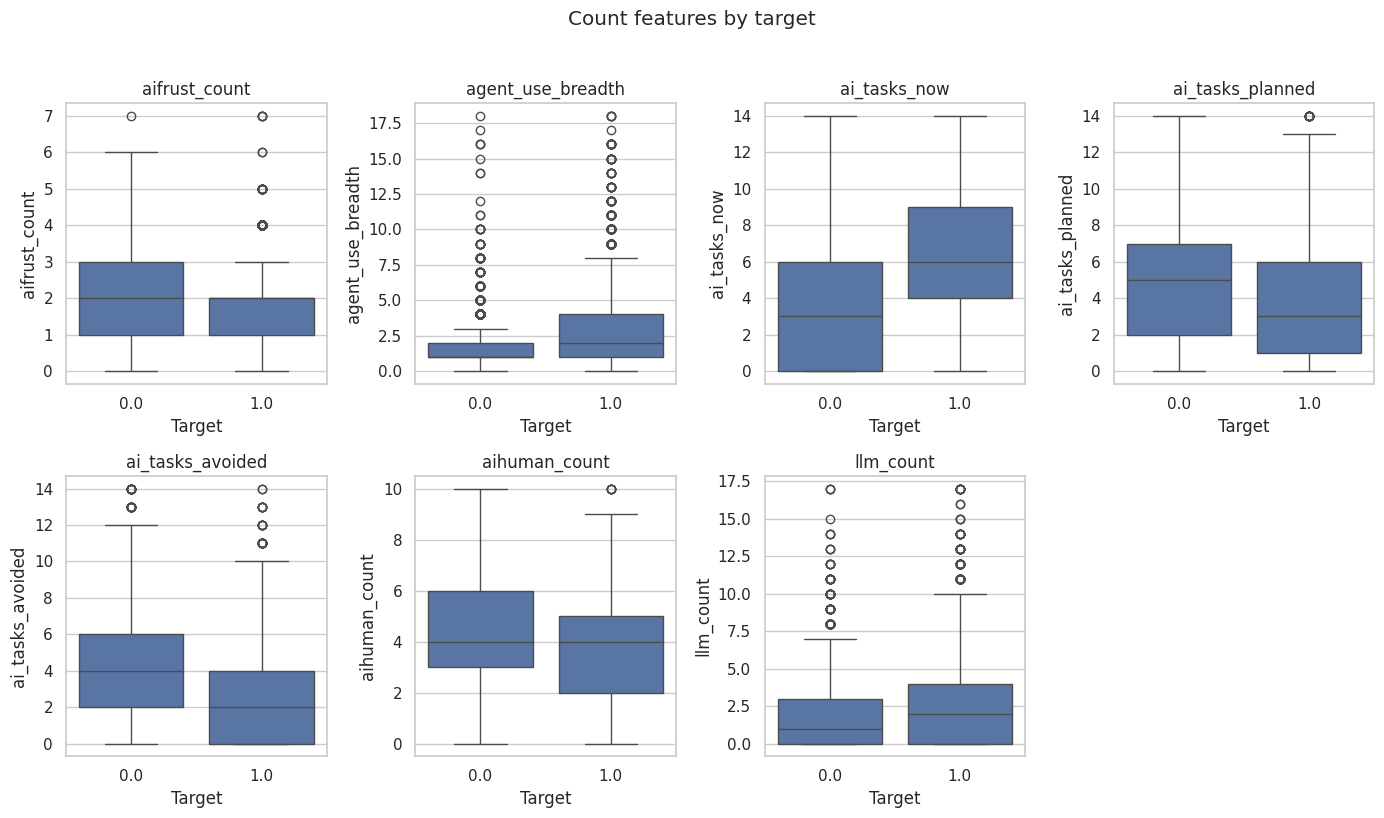

In [10]:
# Plot 3 — Count features vs target (box plots)
count_cols = ["aifrust_count", "agent_use_breadth", "ai_tasks_now", "ai_tasks_planned", "ai_tasks_avoided", "aihuman_count", "llm_count"]
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(count_cols):
    sns.boxplot(data=df, x="target", y=col, ax=axes[i])
    axes[i].set_xlabel("Target")
    axes[i].set_ylabel(col)
    axes[i].set_title(col)
axes[7].set_visible(False)
plt.suptitle("Count features by target", y=1.02)
plt.tight_layout()

`ai_tasks_now` and `ai_tasks_planned` should be higher for agreers (they use AI for more tasks and plan to expand). `llm_count` should be higher (deeper AI ecosystem engagement). `aifrust_count` is ambiguous — heavy AI users encounter more frustrations by using AI more, so agreers can show higher frustration counts. `ai_tasks_avoided` should be lower for agreers (fewer tasks they refuse to use AI for). `aihuman_count` should be lower for agreers (fewer scenarios where they would still prefer a human).

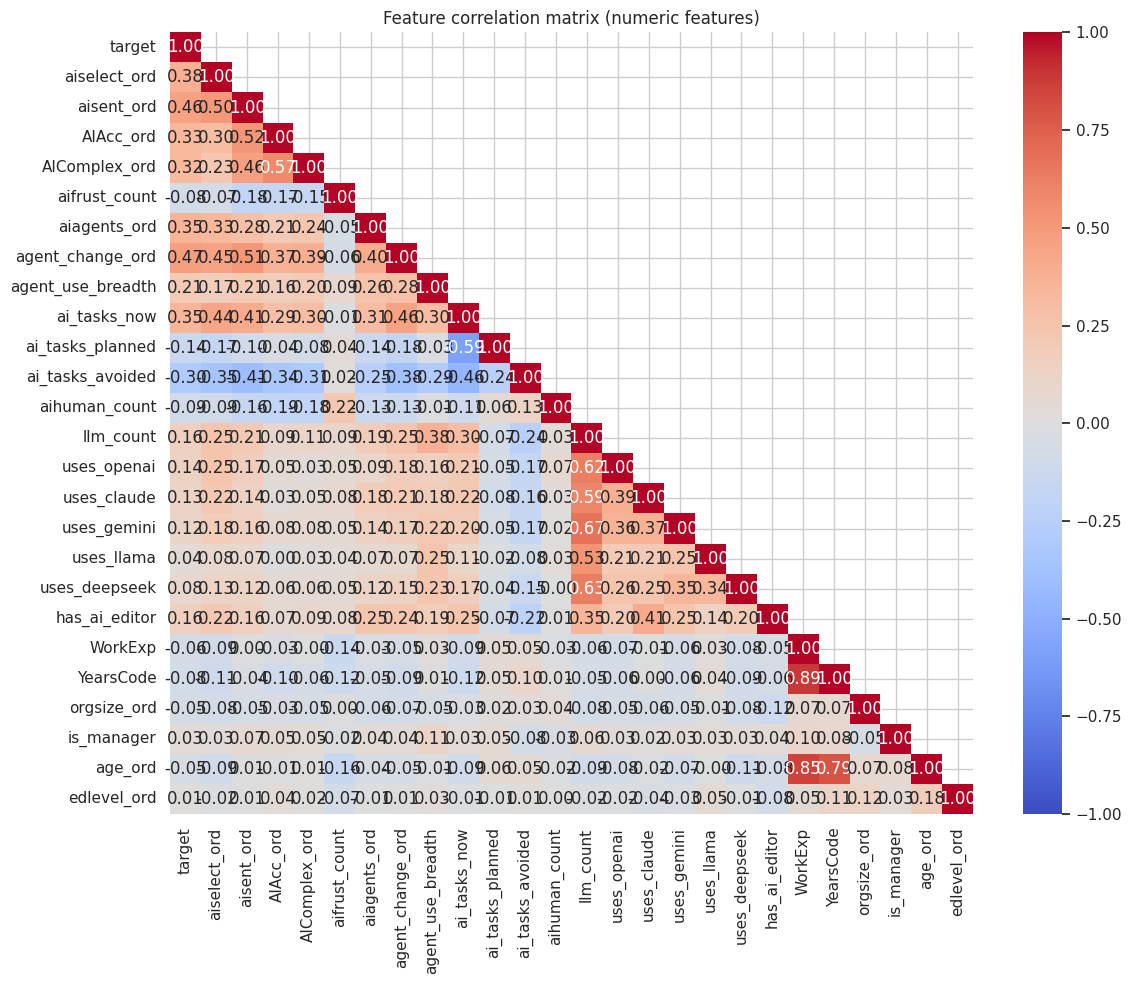

In [11]:
# Plot 4 — Correlation heatmap (numeric + target)
num_for_corr = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) or c == "target"]
df_num = df[num_for_corr].copy()
df_num["target"] = df_num["target"].astype(float)
corr = df_num.corr(method="pearson")
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Feature correlation matrix (numeric features)")
plt.tight_layout()

This plot checks for multicollinearity. The most likely high-correlation pairs are `aiselect_ord` and `aiagents_ord` (both measure AI usage frequency at different granularities) and `aisent_ord` with `AIAcc_ord` (both measure positive AI disposition). If any pair exceeds |0.8|, consider dropping the weaker predictor before modeling. High correlation with target is desirable and indicates predictive power.

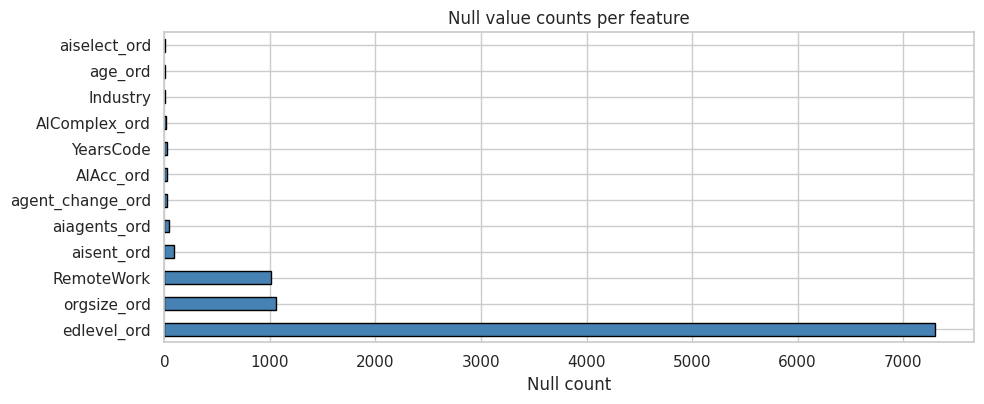

In [12]:
# Plot 5 — Missingness (null counts per feature)
null_counts = df.isna().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, max(4, len(null_counts) * 0.35)))
null_counts.plot(kind="barh", ax=ax, color="steelblue", edgecolor="black")
ax.set_xlabel("Null count")
ax.set_title("Null value counts per feature")
plt.tight_layout()

This plot confirms the missingness audit from Section 5b. `edlevel_ord` dominates at 76.78%, making it by far the most incomplete feature. The remaining columns with non-zero missingness are all below 1.5% and are median-imputed in Section 6 without any indicator.

## 6. Preprocessing

Numeric: median-impute. Add _is_missing only when missingness > 10%.

In [13]:
num_cols = [c for c in df.columns if c not in ["target", "RemoteWork", "Industry"] and pd.api.types.is_numeric_dtype(df[c])]
for c in num_cols:
    miss_rate = df[c].isna().mean()
    if miss_rate > 0:
        if miss_rate > 0.10 and c not in ["orgsize_ord", "edlevel_ord"]:
            df[f"{c}_is_missing"] = df[c].isna().astype(int)
        df[c] = df[c].fillna(df[c].median())

print("Shape before OHE:", df.shape)
print("Columns:", list(df.columns))

Shape before OHE: (9513, 29)
Columns: ['target', 'aiselect_ord', 'aisent_ord', 'AIAcc_ord', 'AIComplex_ord', 'aifrust_count', 'aiagents_ord', 'agent_change_ord', 'agent_use_breadth', 'ai_tasks_now', 'ai_tasks_planned', 'ai_tasks_avoided', 'aihuman_count', 'llm_count', 'uses_openai', 'uses_claude', 'uses_gemini', 'uses_llama', 'uses_deepseek', 'has_ai_editor', 'DevTypeBucket', 'WorkExp', 'YearsCode', 'orgsize_ord', 'is_manager', 'RemoteWork', 'age_ord', 'edlevel_ord', 'Industry']


## 7. Model Prep — OHE

Three string columns are one-hot encoded here. `RemoteWork` expands to 6 categories. `Industry` expands to roughly 10 categories after the 3% frequency collapse in Section 5 merged rare industries into "Other". `DevTypeBucket` expands to 4 categories. The `Other:` → `Other` replacement is applied first so the survey write-in bucket is merged with the collapsed rare-category bucket. `drop_first=False` is used so that interpretation during feature importance analysis stays straightforward. Final shape is 45 columns.

In [14]:
df["Industry"] = df["Industry"].replace("Other:", "Other")
df["RemoteWork"] = df["RemoteWork"].fillna("Unknown")
df["Industry"] = df["Industry"].fillna("Unknown")
ohe = pd.get_dummies(df[["RemoteWork", "Industry", "DevTypeBucket"]], prefix=["RemoteWork", "Industry", "DevType"], drop_first=False)
df = df.drop(columns=["RemoteWork", "Industry", "DevTypeBucket"])
df = pd.concat([df, ohe], axis=1)
print("Final shape:", df.shape)
print("Columns:", list(df.columns))

Final shape: (9513, 45)
Columns: ['target', 'aiselect_ord', 'aisent_ord', 'AIAcc_ord', 'AIComplex_ord', 'aifrust_count', 'aiagents_ord', 'agent_change_ord', 'agent_use_breadth', 'ai_tasks_now', 'ai_tasks_planned', 'ai_tasks_avoided', 'aihuman_count', 'llm_count', 'uses_openai', 'uses_claude', 'uses_gemini', 'uses_llama', 'uses_deepseek', 'has_ai_editor', 'WorkExp', 'YearsCode', 'orgsize_ord', 'is_manager', 'age_ord', 'edlevel_ord', 'RemoteWork_Hybrid (some in-person, leans heavy to flexibility)', 'RemoteWork_Hybrid (some remote, leans heavy to in-person)', 'RemoteWork_In-person', 'RemoteWork_Remote', 'RemoteWork_Unknown', 'RemoteWork_Your choice (very flexible, you can come in when you want or just as needed)', 'Industry_Banking/Financial Services', 'Industry_Fintech', 'Industry_Healthcare', 'Industry_Internet, Telecomm or Information Services', 'Industry_Manufacturing', 'Industry_Other', 'Industry_Retail and Consumer Services', 'Industry_Software Development', 'Industry_Unknown', 'Dev

## 8. Audit

This cell is the final sanity check. Confirm 45 columns total, confirm `target` is present, and confirm no string columns remain (only numeric and bool from OHE).

In [15]:
print(df.shape)
for i, c in enumerate(df.columns):
    print(i + 1, c)

(9513, 45)
1 target
2 aiselect_ord
3 aisent_ord
4 AIAcc_ord
5 AIComplex_ord
6 aifrust_count
7 aiagents_ord
8 agent_change_ord
9 agent_use_breadth
10 ai_tasks_now
11 ai_tasks_planned
12 ai_tasks_avoided
13 aihuman_count
14 llm_count
15 uses_openai
16 uses_claude
17 uses_gemini
18 uses_llama
19 uses_deepseek
20 has_ai_editor
21 WorkExp
22 YearsCode
23 orgsize_ord
24 is_manager
25 age_ord
26 edlevel_ord
27 RemoteWork_Hybrid (some in-person, leans heavy to flexibility)
28 RemoteWork_Hybrid (some remote, leans heavy to in-person)
29 RemoteWork_In-person
30 RemoteWork_Remote
31 RemoteWork_Unknown
32 RemoteWork_Your choice (very flexible, you can come in when you want or just as needed)
33 Industry_Banking/Financial Services
34 Industry_Fintech
35 Industry_Healthcare
36 Industry_Internet, Telecomm or Information Services
37 Industry_Manufacturing
38 Industry_Other
39 Industry_Retail and Consumer Services
40 Industry_Software Development
41 Industry_Unknown
42 DevType_Data/AI
43 DevType_Infras